In [46]:
import tensorflow as tf
from tensorflow import keras
print(tf.__version__)
print(keras.__version__)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

2.19.0
3.10.0


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import pandas as pd
import io
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/housing.csv")
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [49]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [50]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [51]:
# Exclude 'ocean_proximity' and 'total_bedrooms' columns before normalization
numerical_df = df.drop(['ocean_proximity', 'total_bedrooms'], axis=1)
hnorm = ((numerical_df - numerical_df.min()) / (numerical_df.max() - numerical_df.min()))

In [52]:
target = df['median_house_value']
Y = target.values
X = hnorm.values


In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (14448, 8)
Shape of X_test: (6192, 8)
Shape of Y_train: (14448,)
Shape of Y_test: (6192,)


In [54]:
model = tf.keras.models.Sequential([tf.keras.Input(shape=(X_train.shape[1],)),
tf.keras.layers.Dense(16, activation=tf.nn.relu),
tf.keras.layers.Dense(1)])

In [55]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.compile(loss="mae", optimizer="sgd")
history = model.fit(X_train, Y_train, epochs=50,verbose=1)

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 206637.8750
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 97771.9922
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 41383.6367
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6101.4731
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4595.8018
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4560.0879
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4502.1021
Epoch 8/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4357.6206
Epoch 9/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4280.0181
Epoch 10/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4146.5679
Epoch 11/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4091.4751
Epoch 12/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4095.3918
Epoch 13/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3976.8464
Epoch 14/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3960.9292
Epoch 15/50

In [57]:
evaluation_loss = model.evaluate(X_test, Y_test, verbose=0)
print("Evaluation Loss (MAE):", evaluation_loss)

Evaluation Loss (MAE): 2651.50341796875


In [58]:
evaluation_loss = model.evaluate(X_test, Y_test, verbose=0)
print("Evaluation Loss (MAE):", evaluation_loss)

Evaluation Loss (MAE): 2651.50341796875


In [59]:
X_test_50 = X_test[:50]
Y_pred = model.predict(X_test_50)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [60]:
htest = Y_test[:50]

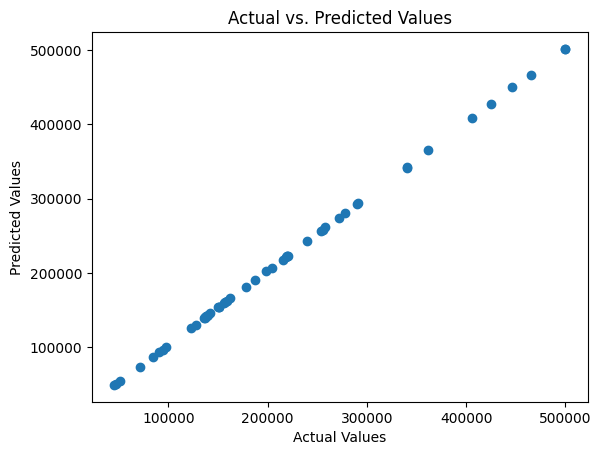

In [61]:
plt.scatter(htest, Y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()

In [62]:
coefficients = np.polyfit(htest, Y_pred.flatten(), 1)

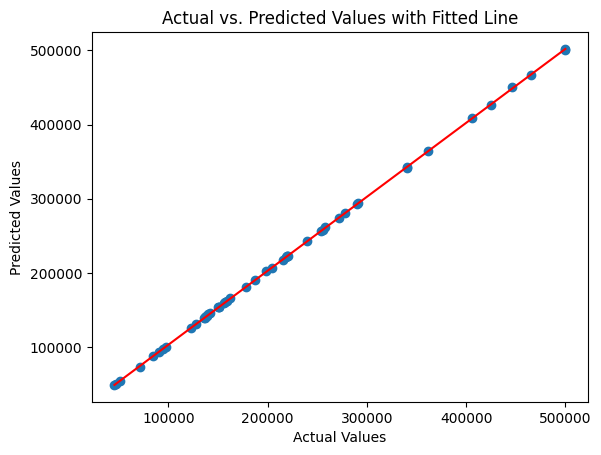

In [63]:
x_values = np.linspace(min(htest), max(htest), 100)
y_values = coefficients[0] * x_values + coefficients[1]
plt.scatter(htest, Y_pred)
plt.plot(x_values, y_values, color='red')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values with Fitted Line")
plt.show()

In [64]:
print("Checking for NaN values in Y_pred:")
print(np.isnan(Y_pred).sum())
if np.isnan(Y_pred).sum() > 0:
    print("NaN values found in Y_pred. Attempting to impute with zero.")
    Y_pred_cleaned = np.nan_to_num(Y_pred, nan=0)
else:
    Y_pred_cleaned = Y_pred

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(htest, Y_pred_cleaned)
mse = mean_squared_error(htest, Y_pred_cleaned)
r2 = r2_score(htest, Y_pred_cleaned)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

Checking for NaN values in Y_pred:
0
Mean Absolute Error (MAE): 2636.4353125
Mean Squared Error (MSE): 7466582.013703614
R-squared (R2): 0.999455140948618
